# Tarea 69 - Iris Dataset
Implementa usando PyTorch y siguiendo la domcumentación un clasificador para el dataset Iris.

## Imports 

In [96]:
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset

import torch.nn.functional as F
import torch.nn as nn
from torch.utils.data import random_split
from torch.utils.tensorboard import SummaryWriter

## Pasos previos
1. Cargar o dataset
2. Esudiarlo: Ver algún dato, pintar alguna gráfica
3. Tranformación de datos

### Importar dataset Iris

In [97]:
irisDataset = pd.read_csv("../data/iris/iris.data", #TODO: aperez: Poner dos puntos para que salga de notebooks y entre en data
                          names=["sepallength","sepalwidth",
                                 "petallength","petalwidth","class"])

### Estudio dataset. Datos, mostrar gráficas...

In [98]:
irisDataset.head(4)

,sepallength,sepalwidth,petallength,petalwidth,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa


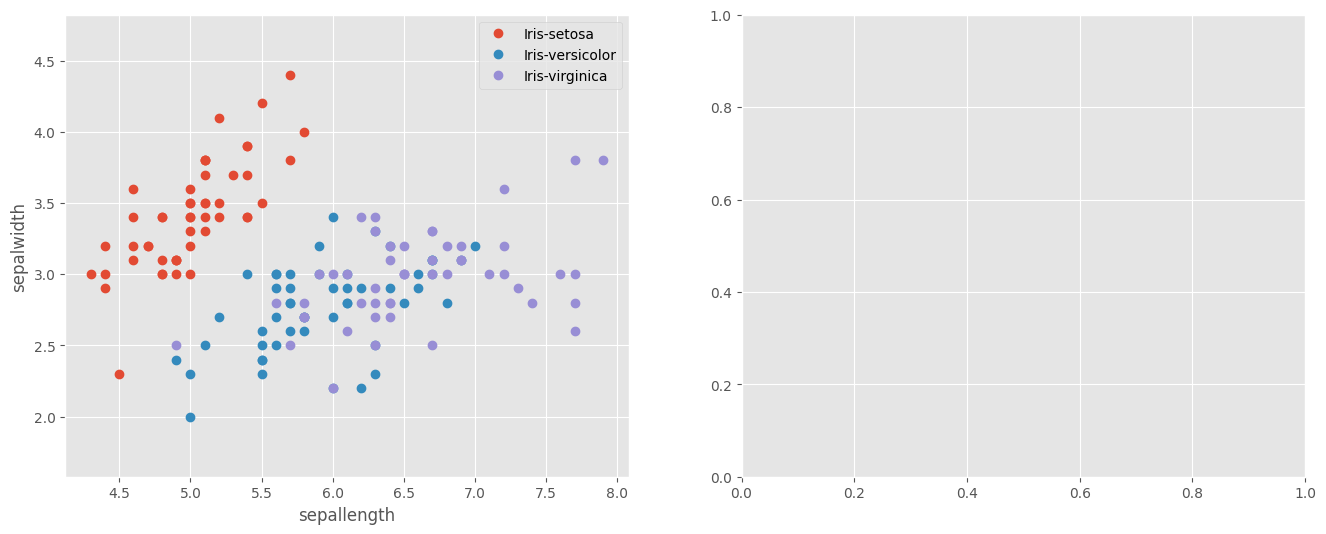

In [99]:
plt.style.use('ggplot')
nomeClases = irisDataset["class"].unique()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
for target, target_name in enumerate(nomeClases):
    X_plot = irisDataset[irisDataset["class"] == target_name]
    ax1.plot(X_plot["sepallength"], X_plot["sepalwidth"], 
             linestyle='none', 
             marker='o', 
             label=target_name)
ax1.set_xlabel("sepallength")
ax1.set_ylabel("sepalwidth")
ax1.axis('equal')
ax1.legend()

### Trasformación de Datos

Para trabajar bien con los datos de una red de neuronas, tenenmos que hacer alguna que otra transformación en los datos de entrada
- No podemos trabajar con entradas categóricas (class)
- Los valores de entrada están mejor con media 0 y desviación típica 1
Se puede hacer una clase que haga transformación del tipo de otro frameworks

In [100]:
class StandardScaler:

    def __init__(self, mean=None, std=None, epsilon=1e-7):
        """Standard Scaler.
        The class can be used to normalize PyTorch Tensors using native functions. The module does not expect the
        tensors to be of any specific shape; as long as the features are the last dimension in the tensor, the module
        will work fine.
        :param mean: The mean of the features. The property will be set after a call to fit.
        :param std: The standard deviation of the features. The property will be set after a call to fit.
        :param epsilon: Used to avoid a Division-By-Zero exception.
        """
        self.mean = mean
        self.std = std
        self.epsilon = epsilon
    def fit(self, values):
        dims = list(range(values.dim() - 1))
        self.mean = torch.mean(values, dim=dims)
        self.std = torch.std(values, dim=dims)
    def transform(self, values):
        return (values - self.mean) / (self.std + self.epsilon)

    def fit_transform(self, values):
        self.fit(values)
        return self.transform(values)

    def __repr__(self):
        return f"mean: {self.mean}, std:{self.std}, epsilon:{self.epsilon}"

### Datasets en PyTorch

Para evitar que el código de lectura de datos se vuelva caótico y difícil de mantener, PyTorch centraliza este proceso usando Datasets y DataLoaders.
- **El rol del Dataset**: Es el objeto responsable de almacenar, leer y adaptar la información. PyTorch no hace distinción entre sus Datasets predefinidos y los que tú decidas crear desde cero; ambos se tratan igual en el ecosistema.
- **Creación de un Dataset personalizado**: Para hacer uno propio, debes crear una clase en Python que herede de torch.utils.data.Dataset.
Esta clase personalizada debe implementar obligatoriamente tres métodos fundamentales:
1. __ init__: Es el constructor. Aquí debes leer los datos originales y dejarlos preparados en memoria.
2. __ len__: Debe devolver el número total de patrones o muestras que tiene tu conjunto de datos.
3. __ getitem__: Es el encargado de extraer y devolver un patrón o muestra individual cuando se le pide.

In [101]:
class IrisDataset(Dataset):
  def __init__(self, src_file, root_dir, transform=None):
    irisDataset = pd.read_csv(src_file, names=["sepallength","sepalwidth","petallength","petalwidth","class"])
    X = irisDataset[irisDataset.columns.intersection(["sepallength","sepalwidth","petallength","petalwidth"])]
    Y = irisDataset[irisDataset.columns.intersection(["class"])]
    nomeClases = Y["class"].unique()
    conversion = {v: k for k, v in dict(enumerate(nomeClases)).items()}
    YConversion = pd.DataFrame()
    for nome in nomeClases:
      YConversion[nome] = (Y["class"]==nome).apply(lambda x : 1.0 if x else 0.0)
    y_tensor = torch.as_tensor(YConversion.to_numpy()).type(torch.float32)
    df_dict = dict.fromkeys(X.columns, '')
    X.rename(columns = df_dict)
    s1=X.iloc[:,0:4].values
    x_tensor = torch.tensor(s1)
    scaler = StandardScaler()
    scaler.fit(x_tensor)
    XScalada = scaler.fit_transform(x_tensor).type(torch.float32)
    self.data = torch.cat((XScalada,y_tensor),1)
    self.root_dir = root_dir
    self.transform = transform
  def __len__(self):
    return len(self.data)

  def __getitem__(self, idx):
    if torch.is_tensor(idx):
      idx = idx.tolist()
    preds = self.data[idx, 0:4]
    spcs = self.data[idx, 4:]
    sample = (preds, spcs)
    if self.transform:
      sample = self.transform(sample)
    return sample

### Carga de datos por IrisDataset

No viene mal acceder al primer elemento, por ver si algo sale mal

In [102]:
dataset = IrisDataset("../data/iris/iris.data",".")
display(dataset[0]) # comprobamos que sale algo

(tensor([-0.8977,  1.0286, -1.3368, -1.3086]), tensor([1., 0., 0.]))

## División en Train y Test
- No se puede añadir elementos a untensor después de la creación
- Pero podemos crear un nuevo tensor que una dos tensor, para eso está la función **cat**

In [103]:
lonxitudeDataset = len(dataset)
tamTrain =int(lonxitudeDataset*0.8)
tamVal = int(lonxitudeDataset*0.2)

train_set, val_set = random_split(dataset, [tamTrain, tamVal]) # TODO: aperez: Faltaba esta linea para futuros proyectos

print(f"Tam dataset: {lonxitudeDataset} train: {tamTrain} tamVal: {tamVal}")
train_ldr = torch.utils.data.DataLoader(train_set, batch_size=2,
    shuffle=True, drop_last=False)
# TODO: aperez: num_workers=2 -> S.O: Linux o macOS, PyTorch puede crear "clones" (forks) del proceso principal muy fácilmente para que carguen los datos en paralelo
#               En Windowns maneja el multiprocesamiento de forma diferente (usa algo llamado spawn). Al intentar crear estos subprocesos dentro de un Notebook, 
#               Windows se lía intentando recargar todo tu código desde cero, y los trabajadores colapsan. Ponemos a 0!!

# validation_loader =torch.utils.data.DataLoader(val_set, batch_size=4, shuffle=False, num_workers=2)
validation_loader =torch.utils.data.DataLoader(val_set, batch_size=4, shuffle=False, num_workers=0)   

Tam dataset: 150 train: 120 tamVal: 30


## Creación del Modelo
- El modelo tiene que derivar de la clase **torch.nn.Module**
- Deberiamos tener el método __ init__ y el método **forward**
    - En init hay que definir la estructura del modelo: capas que tiene, tipo de capa, elementos en cada capa
    - En forward hay que indicar como se hace el cálculo cara delante: a partir de una entrada obtener la salida

In [104]:
class Model(nn.Module):
    def __init__(self, input_dim):
        super(Model, self).__init__()
        self.layer1 = nn.Linear(input_dim, 50)
        self.layer2 = nn.Linear(50, 50)
        self.layer3 = nn.Linear(in_features=50, out_features=3)
        
    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = F.softmax(self.layer3(x), dim=1)
        return x

- Para las capas usamos *Linear*
    - El primer parámetro es el tamaño de entrada
    - El segundo parámetro es la salida
- Para el cálculo de la salida usamos relu e softmax

## Instanciar el Modelo
- Una vez instanciado el modelo hay:
    - Instanciarlo
    - Definir el optimizador
    - Definir la función de error
- Para este dataset utilizaremos optimizadores **Adam** y **CrossEntropyLoss**

In [105]:
model     = Model(4) #TODO: aperez: IMPORTANTE!! Tiene que coincidir con el número de características de entrada (features) que tiene cada patrón
                     # Al ser el datset de Iris , tiene 4 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn   = nn.CrossEntropyLoss()
display(model)

Model(
  (layer1): Linear(in_features=4, out_features=50, bias=True)
  (layer2): Linear(in_features=50, out_features=50, bias=True)
  (layer3): Linear(in_features=50, out_features=3, bias=True)
)

### Prueba
No está de más probar que todo en este proceso encaja y hacer una simulación de una iteración de entrenamientoss

In [106]:
entradaProba,dest = next(iter(train_ldr))
print("Entrada:")
display(entradaProba)
print("Desexada:")
display(dest)
saida = model(entradaProba) # esta é a proba de verdade
print("Saída:")
display(saida)
loss_fn(saida, dest)

Entrada:


tensor([[ 1.1553, -0.5858,  0.5902,  0.2638],
        [-0.7769,  1.0286, -1.2801, -1.3086]])

Desexada:


tensor([[0., 1., 0.],
        [1., 0., 0.]])

Saída:


tensor([[0.2873, 0.3620, 0.3507],
        [0.2753, 0.3764, 0.3483]], grad_fn=<SoftmaxBackward0>)

tensor(1.1140, grad_fn=<DivBackward1>)

## Función de entrenamiento
- Ahora se trata de hacer una función que haga una iteración simple de entrenamiento (epoch) sobre una entrada
    -  Se recoge cada uno de los grupos de entrada
        1. Separamos entre datos de entrada y salida deseada
        2. Se pone los gradientes a cero
        3. Se calcula la salida
        4. Se calcula el error en la salida en las capas intermedias
        5. Modificamos pesos 
        6. Capturamos información para informes

In [107]:
def train_one_epoch(epoch_index, tb_writer):
    running_loss = 0.
    last_loss = 0.
    # usamos enumerate para saber en que batch imos
    for i, data in enumerate(train_ldr):
        # Every data instance is an input + label pair
        inputs, labels = data
        # Zero your gradients for every batch!
        optimizer.zero_grad()
        # Make predictions for this batch
        outputs = model(inputs)
        # Compute the loss and its gradients
        loss = loss_fn(outputs, labels)
        loss.backward()
        # Adjust learning weights
        optimizer.step()
        # Gather data and report
        running_loss += loss.item()
        if i % 10 == 9:
            last_loss = running_loss / 10 # loss per batch
            print('  batch {} loss: {}'.format(i + 1, last_loss))
            running_loss = 0.
    return last_loss

- El entrenamiento consiste en ir pasando la función anterior unas cuantas veces en bucle y validando el entrenamiento con el test
- El test se puede hacer al final o durante el propio entrenamiento (depende la información que queramos ver)

In [108]:
EPOCHS = 100
loss_list     = torch.zeros((EPOCHS,))
accuracy_list = torch.zeros((EPOCHS,))
writer = SummaryWriter('runs/experimento_iris')
for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch + 1))

    # Poñemos o modelo en modo entrenamento
    model.train(True)
    avg_loss = train_one_epoch(epoch, writer)
    loss_list[epoch] = avg_loss
    # Non se precisan os gradientes para o test
    model.train(False)

EPOCH 1:
  batch 10 loss: 1.0941601991653442
  batch 20 loss: 1.0781588673591613
  batch 30 loss: 1.038159054517746
  batch 40 loss: 1.007117784023285
  batch 50 loss: 1.0088947355747222
  batch 60 loss: 0.9237379252910614
EPOCH 2:
  batch 10 loss: 0.907025146484375
  batch 20 loss: 0.8514988958835602
  batch 30 loss: 0.8499947309494018
  batch 40 loss: 0.8136716604232788
  batch 50 loss: 0.7061339676380157
  batch 60 loss: 0.7543010473251343
EPOCH 3:
  batch 10 loss: 0.7649088263511657
  batch 20 loss: 0.6909356355667114
  batch 30 loss: 0.7691661775112152
  batch 40 loss: 0.7215896189212799
  batch 50 loss: 0.705091118812561
  batch 60 loss: 0.6523992776870727
EPOCH 4:
  batch 10 loss: 0.7121248364448547
  batch 20 loss: 0.6482694208621979
  batch 30 loss: 0.671898466348648
  batch 40 loss: 0.6387723684310913
  batch 50 loss: 0.7228223979473114
  batch 60 loss: 0.6870305120944977
EPOCH 5:
  batch 10 loss: 0.7083711087703705
  batch 20 loss: 0.6823358833789825
  batch 30 loss: 0.64453

- Si además queremos ir valindando

In [109]:
running_vloss = 0.0
for i, vdata in enumerate(validation_loader):
    vinputs, vlabels = vdata
    voutputs = model(vinputs)
    vloss = loss_fn(voutputs, vlabels)

    correct = (torch.argmax(voutputs, dim=0) == vlabels).type(torch.FloatTensor)
    accuracy_list[epoch] += correct.sum()
    running_vloss += vloss

    avg_vloss = running_vloss / (i + 1)
    print('LOSS train {} valid {} {}/{}'.format(avg_loss, avg_vloss,accuracy_list[epoch],int(lonxitudeDataset*0.2)))


LOSS train 0.5515567719936371 valid 0.5514826774597168 2.0/30
LOSS train 0.5515567719936371 valid 0.5515347719192505 7.0/30
LOSS train 0.5515567719936371 valid 0.5515435338020325 14.0/30
LOSS train 0.5515567719936371 valid 0.5515203475952148 15.0/30
LOSS train 0.5515567719936371 valid 0.5515052676200867 15.0/30
LOSS train 0.5515567719936371 valid 0.5514952540397644 16.0/30
LOSS train 0.5515567719936371 valid 0.5872068405151367 20.0/30
LOSS train 0.5515567719936371 valid 0.582736611366272 20.0/30


## Mostrar alguna gráfica

Text(0.5, 0, 'epochs')

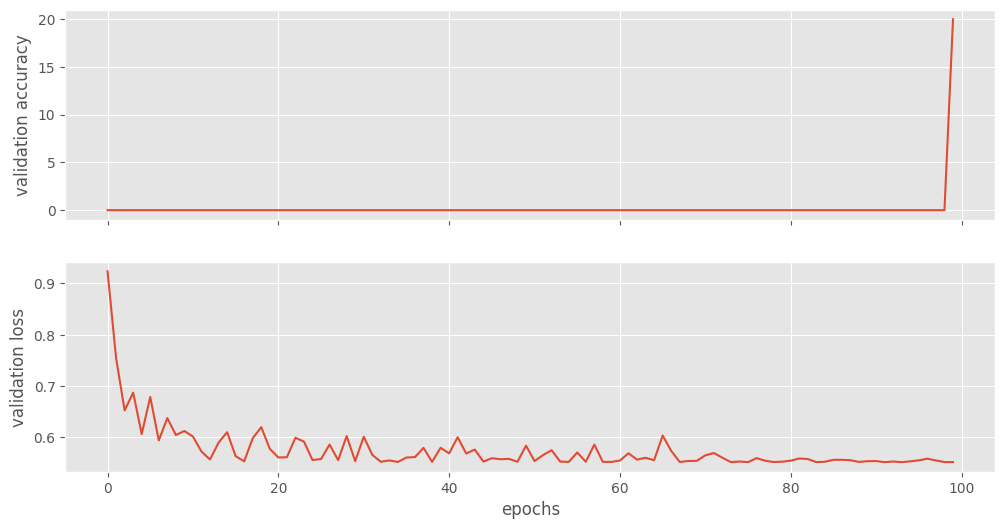

In [110]:
plt.style.use('ggplot')
fig, (ax1, ax2) = plt.subplots(2, figsize=(12, 6), sharex=True)

ax1.plot(accuracy_list)
ax1.set_ylabel("validation accuracy")
ax2.plot(loss_list)
ax2.set_ylabel("validation loss")
ax2.set_xlabel("epochs")